# Solar System Demo

This notebook demonstrates the N-body cluster simulator on a simplified case: a single Sun-like star with the eight planets of the Solar System. It reuses the existing `cluster_sim` package (generators, integrator, and visualization) without modifying it.

In [1]:
# Make the repository root importable so we can use the cluster_sim package
import os
import sys

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
from IPython.display import Image, display

from cluster_sim.constants import AU, M_sun
from cluster_sim.generators import planet
from cluster_sim.integrator import Hermite
from cluster_sim.visual import plot_trajectories

## Build the Solar System

We start with a single star (the Sun) at rest at the origin, then use the existing `planet` generator to attach the eight planets on circular orbits.

In [2]:
# A single Sun-like star at the origin, at rest
x = np.array([0.0])
y = np.array([0.0])
z = np.array([0.0])
vx = np.array([0.0])
vy = np.array([0.0])
vz = np.array([0.0])
masses = np.array([M_sun])
is_star = np.array([True])

sun_index = 0
x, y, z, vx, vy, vz, masses, is_star = planet(x, y, z, vx, vy, vz, masses, is_star, sun_index)

body_names = ["Sun", "Mercury", "Venus", "Earth", "Mars", "Jupiter", "Saturn", "Uranus", "Neptune"]
print(f"Initialized {len(masses)} bodies: {', '.join(body_names)}")

Initialized 9 bodies: Sun, Mercury, Venus, Earth, Mars, Jupiter, Saturn, Uranus, Neptune


## Run the Hermite Integrator

A short run (a few Earth years) is enough to trace out the inner planets' orbits and show the outer planets moving along their paths.

In [8]:
dt = 86400.0                 # Baseline timestep: 1 day
year = 31557600.0
tmax = 100.0 * year            # Simulate 100 Earth years
nu = 0.01                    # Timestep accuracy parameter
n_order = 3                  # Predictor-corrector iterations
data_interval = 5.0 * dt     # Record diagnostics every 5 days
progress_interval = 0.2 * tmax

results = Hermite(
    x, y, z, vx, vy, vz, masses,
    dt, tmax, nu, n_order, is_star,
    None, data_interval,
    progress_interval=progress_interval
)
(
    xl, yl, zl, vxl, vyl, vzl,
    kel, gpel, tel, eccenl, angl, pl, al, ebl, timel
) = results

print(f"Recorded {len(timel)} snapshots over the run.")

Integration progress: 20.0% (20.0 simulated years), timestep=1.21e+05 s
Integration progress: 40.0% (40.0 simulated years), timestep=1.21e+05 s
Integration progress: 60.0% (60.0 simulated years), timestep=1.21e+05 s
Integration progress: 80.0% (80.0 simulated years), timestep=1.21e+05 s
Integration progress: 100.0% (100.0 simulated years), timestep=9.75e+04 s
3155760000.0
26106
Recorded 7305 snapshots over the run.


## Visualize the Orbits

Reuse `plot_trajectories` from `cluster_sim.visual`, plotted relative to the Sun so the planetary orbits are centered.

✓ Trajectory plot saved to: ..\data\processed\test\solar_system_demo.png


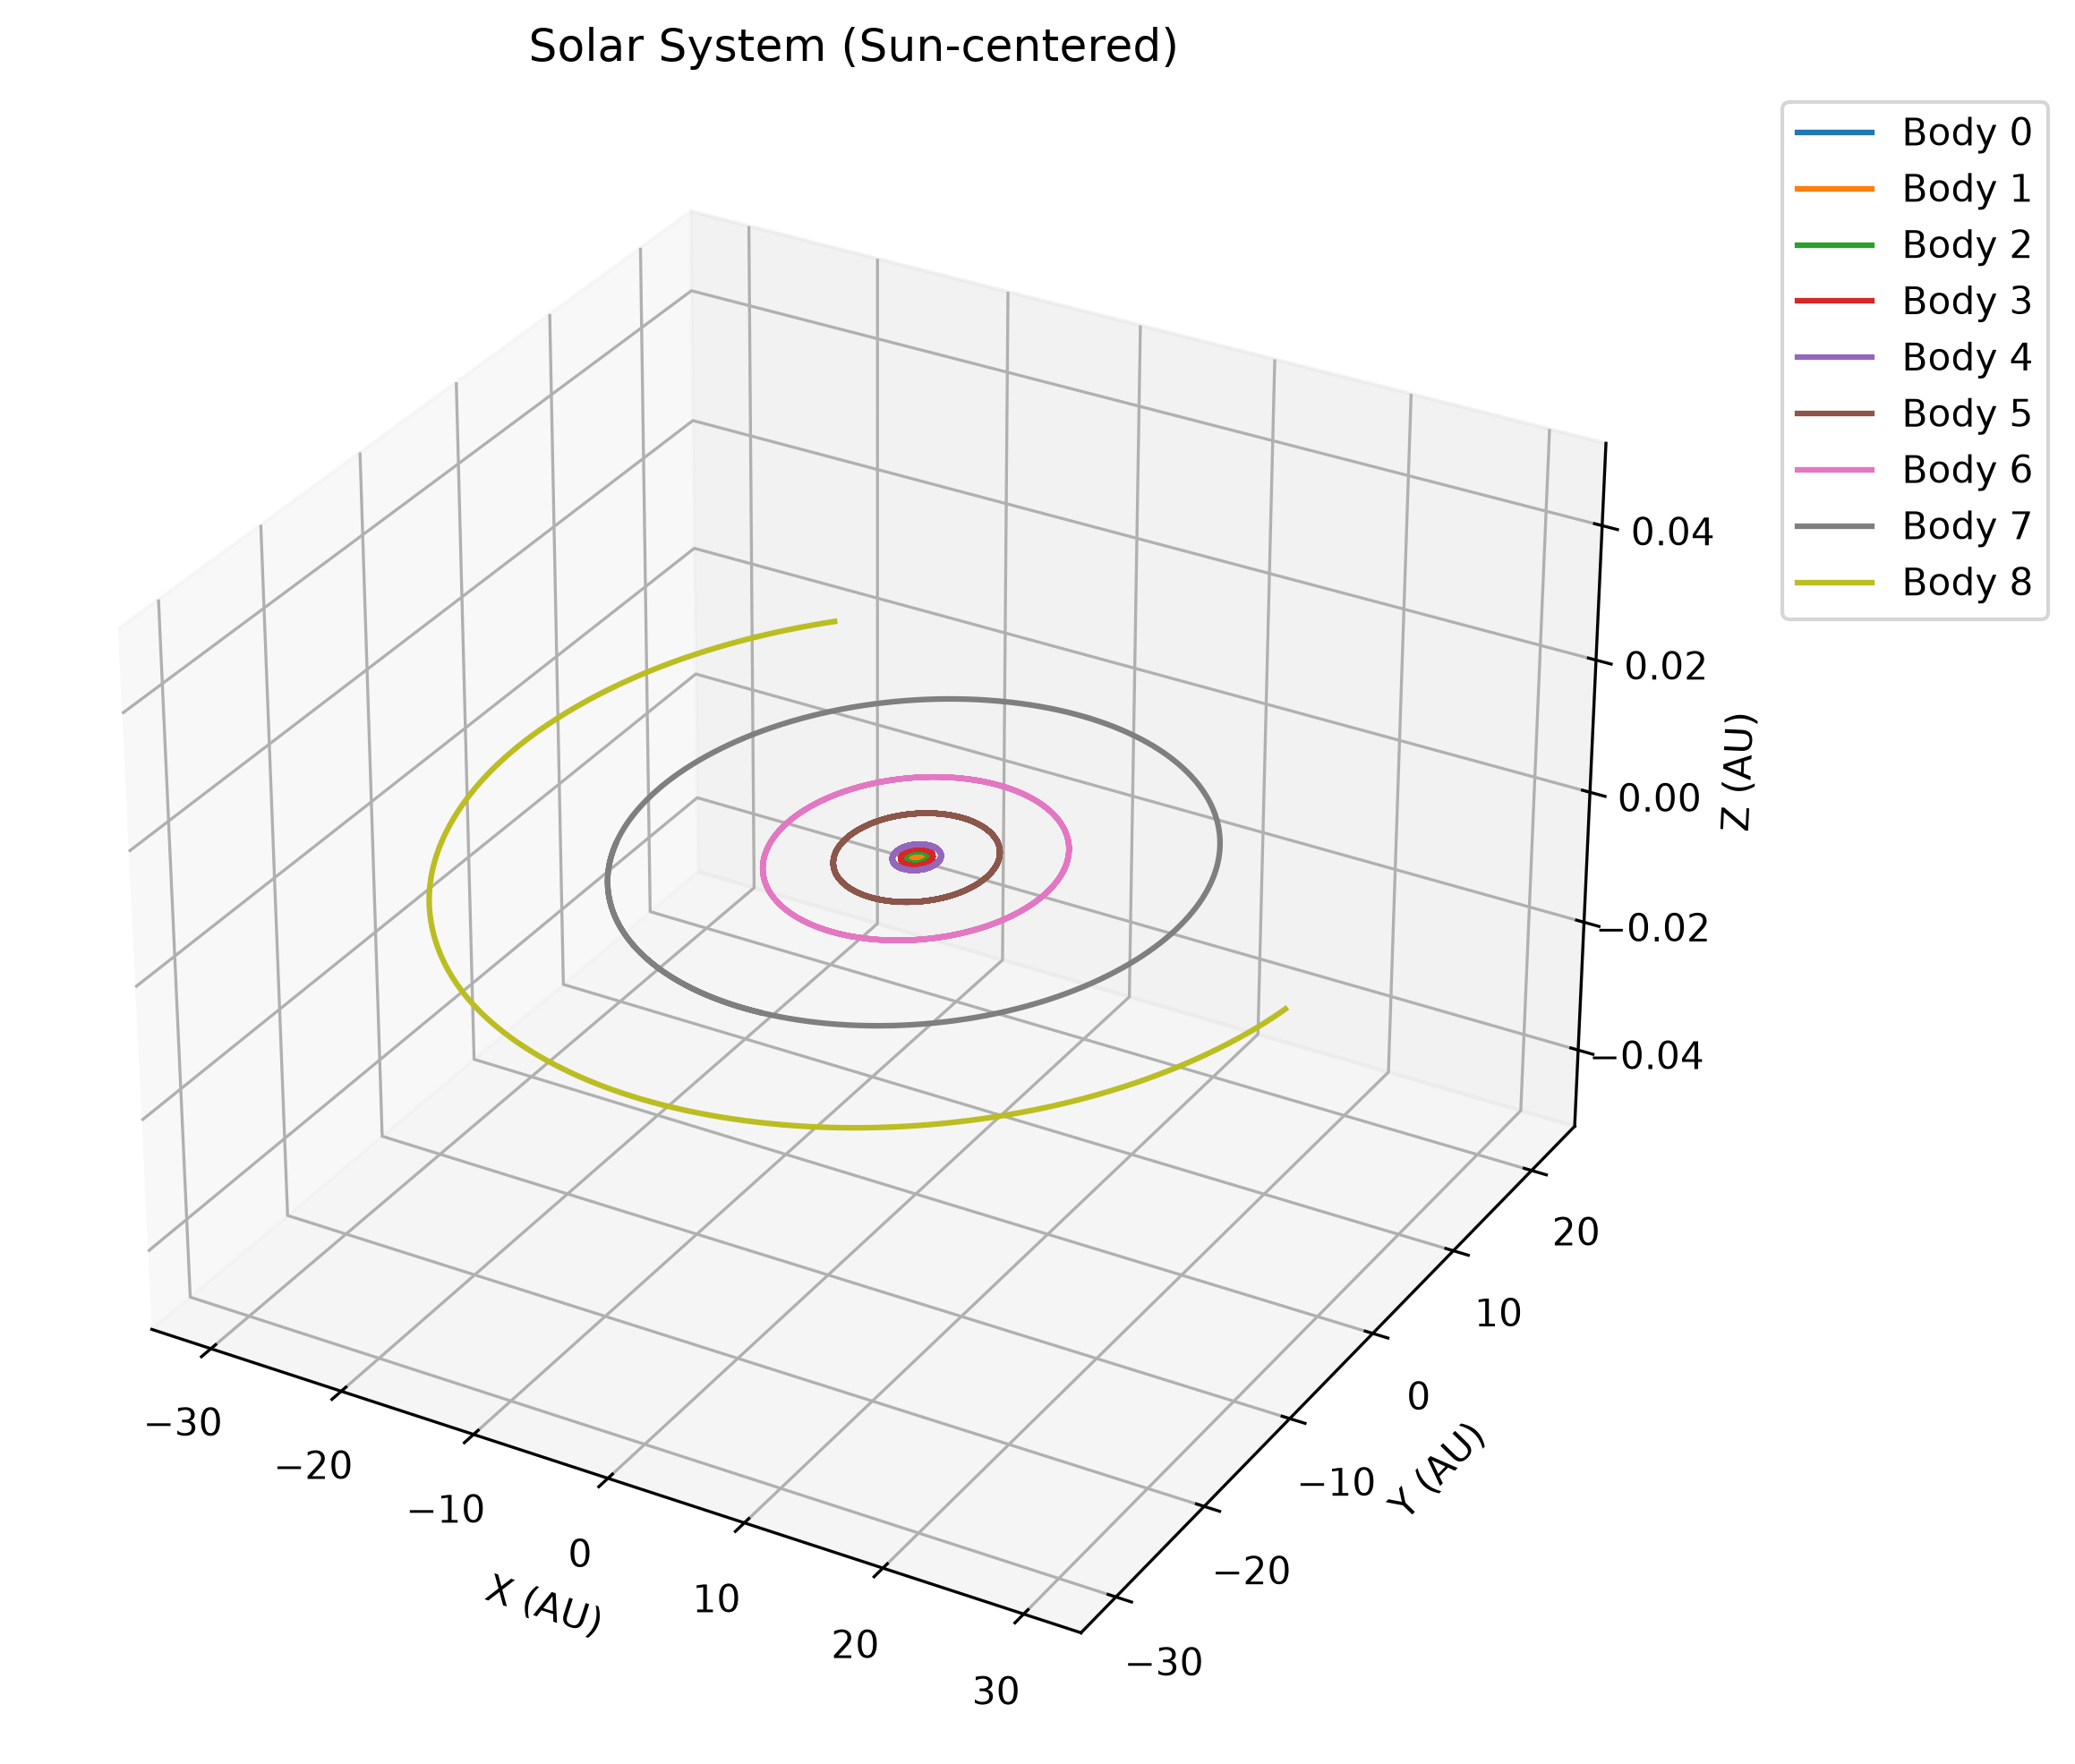

In [9]:
plot_path = os.path.join("..", "data", "processed", "test", "solar_system_demo.png")

plot_trajectories(
    xl, yl, zl, len(masses),
    save_path=plot_path,
    reference_index=sun_index,
    unit_scale=AU,
    unit_label="AU",
    title="Solar System (Sun-centered)"
)

display(Image(filename=plot_path))

## Energy Conservation Check

A quick sanity check using the kinetic, potential, and total energy already returned by the integrator.

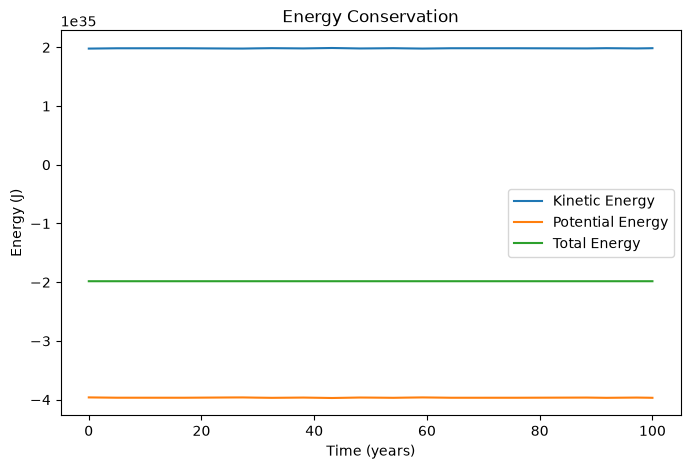

In [10]:
import matplotlib.pyplot as plt

years = np.array(timel) / year

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(years, kel, label="Kinetic Energy")
ax.plot(years, gpel, label="Potential Energy")
ax.plot(years, tel, label="Total Energy")
ax.set_xlabel("Time (years)")
ax.set_ylabel("Energy (J)")
ax.set_title("Energy Conservation")
ax.legend()
plt.show()